#### Generate toy dataset

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from random import randint, choice

IMG_SIZE = 128
NUM_IMAGES = 1000
SHAPES = ['circle', 'square', 'triangle']
SHAPE_LABELS = {'circle': 1, 'square': 2, 'triangle': 3}

def draw_circle(img, x, y, size):
    cx, cy = x + size//2, y + size//2
    r = size//2
    for i in range(y, min(y+size, IMG_SIZE)):
        for j in range(x, min(x+size, IMG_SIZE)):
            if (i-cy)**2 + (j-cx)**2 <= r**2:
                img[i, j] = 255
    return img

def draw_square(img, x, y, size):
    img[y:min(y+size, IMG_SIZE), x:min(x+size, IMG_SIZE)] = 255
    return img

def draw_triangle(img, x, y, size):
    
    def area(a, b, c):
        return abs((b[0]-a[0])*(c[1]-a[1]) - (c[0]-a[0])*(b[1]-a[1])) / 2
    
    p1 = np.array([x + size//2, y])
    p2 = np.array([x, y + size])
    p3 = np.array([x + size, y + size])
    
    min_x = max(0, int(min(p1[0], p2[0], p3[0])))
    max_x = min(IMG_SIZE, int(max(p1[0], p2[0], p3[0])) + 1)
    min_y = max(0, int(min(p1[1], p2[1], p3[1])))
    max_y = min(IMG_SIZE, int(max(p1[1], p2[1], p3[1])) + 1)
    
    total_area = area(p1, p2, p3)
    
    for i in range(min_y, max_y):
        for j in range(min_x, max_x):
            p = np.array([j, i])
            a1 = area(p, p2, p3)
            a2 = area(p1, p, p3)
            a3 = area(p1, p2, p)
            if abs(total_area - (a1 + a2 + a3)) < 1e-6:
                img[i, j] = 255
    return img

def check_overlap(b1, b2):
    x1, y1, w1, h1 = b1
    x2, y2, w2, h2 = b2
    xi1, yi1 = max(x1, x2), max(y1, y2)
    xi2, yi2 = min(x1+w1, x2+w2), min(y1+h1, y2+h2)
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    area1, area2 = w1*h1, w2*h2
    iou = inter / (area1 + area2 - inter) if (area1 + area2 - inter) > 0 else 0
    return iou > 0.1

def draw_shape_on_image(img, shape, size, x, y):
    if shape == 'circle':
        img = draw_circle(img, x, y, size)
    elif shape == 'square':
        img = draw_square(img, x, y, size)
    elif shape == 'triangle':
        img = draw_triangle(img, x, y, size)
    return img

def create_dataset():
    dataset = []
    for _ in range(NUM_IMAGES):
        img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        num_shapes = randint(1, 3)
        shapes_info = []
        bboxes = []
        
        for __ in range(num_shapes):
            for attempt in range(30):
                shape = choice(SHAPES)
                size = randint(15, 40)
                x = randint(10, IMG_SIZE - size - 10)
                y = randint(10, IMG_SIZE - size - 10)
                new_bbox = [x, y, size, size]
                
                overlap = False
                for b in bboxes:
                    if check_overlap(new_bbox, b):
                        overlap = True
                        break
                
                if not overlap:
                    img = draw_shape_on_image(img, shape, size, x, y)
                    
                    shapes_info.append({
                        'bbox': new_bbox,
                        'label': SHAPE_LABELS[shape],
                        'type': shape
                    })
                    bboxes.append(new_bbox)
                    break
        
        dataset.append({'image': img, 'shapes': shapes_info})
    return dataset

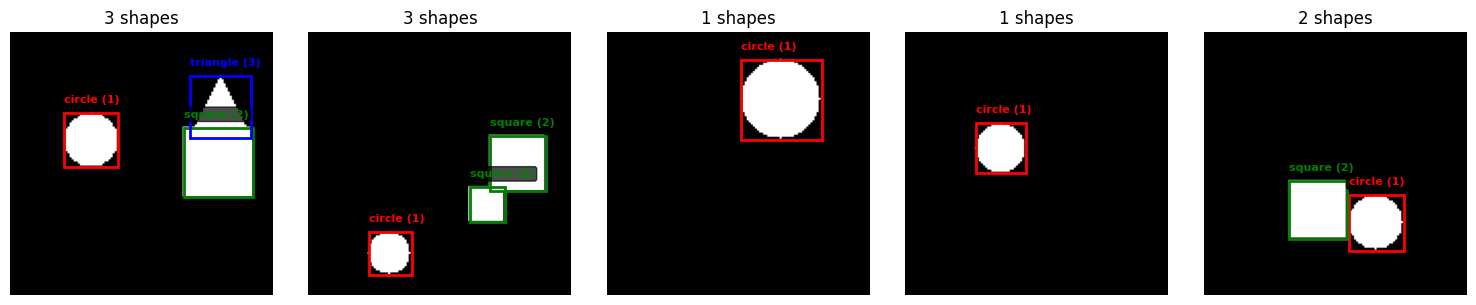

Total images: 1000
Total shapes: 2006
Avg shapes/image: 2.01


In [89]:
dataset = create_dataset()

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
colors = {'circle': 'red', 'square': 'green', 'triangle': 'blue'}

for i in range(5):
    img = dataset[i]['image']
    img_rgb = np.stack([img, img, img], axis=2)
    axes[i].imshow(img_rgb)
    
    for shape in dataset[i]['shapes']:
        x, y, w, h = shape['bbox']
        rect = patches.Rectangle((x, y), w, h, linewidth=2, 
                                edgecolor=colors[shape['type']], facecolor='none')
        axes[i].add_patch(rect)
        axes[i].text(x, y-5, f"{shape['type']} ({shape['label']})", 
                    color=colors[shape['type']], fontsize=8, weight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.7))
    
    axes[i].set_title(f'{len(dataset[i]["shapes"])} shapes')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"Total images: {len(dataset)}")
total_shapes = sum(len(s['shapes']) for s in dataset)
print(f"Total shapes: {total_shapes}")
print(f"Avg shapes/image: {total_shapes/len(dataset):.2f}")

##### Prepare dataset for model

In [90]:
DATA_SPLIT_RATIO = 0.9
NUM_TRAIN_DATA = int(DATA_SPLIT_RATIO * NUM_IMAGES)
X_train, X_test, y_train, y_test = list(), list() , list(), list()

for i in range(NUM_TRAIN_DATA):
    X_train.append(dataset[i]["image"])
    y_train.append(dataset[i]["shapes"])

for i in range(NUM_TRAIN_DATA , NUM_IMAGES):
    X_test.append(dataset[i]["image"])
    y_test.append(dataset[i]["shapes"])


In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset

class ImgDataset(Dataset):
    def __init__(self, features_list: list[dict], labels_list: list[dict]): 
        self.features = features_list
        self.labels = labels_list

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        x = torch.tensor(self.features[idx], dtype = torch.float32)
        y = []
        for shape in self.labels[idx]:
            bbox = shape['bbox']
            label = shape['label']
            y.append({
                'boxes': torch.tensor(bbox, dtype=torch.float32),
                'labels': torch.tensor([label], dtype=torch.int64)
            })
        return x, y
    
def collate_fn(batch):
    images = []
    all_targets = []
    
    for img, targets in batch:
        images.append(img)
        all_targets.append(targets)
    
    images = torch.stack(images, 0)
    return images, all_targets

In [ ]:
train_dataset = ImgDataset(X_train, y_train)
test_dataset = ImgDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size= 16, shuffle= True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size= 16, shuffle= True , collate_fn=collate_fn)

##### Implement spase RCNN

In [100]:
import torch.nn as nn

class Sparse_RCNN(nn.Module):
    def __init__(self, in_channel: int, out_channel: int, 
                num_learning_proposals: int, num_learnable_proposal_features: int,
                num_classes: int):
        super().__init__()

        self.backbone = nn.Sequential(
            nn.Conv2d(in_channels=in_channel, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(in_channels=64, out_channels= out_channel, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2)
        )

        self.proposal_boxes = nn.Parameter(torch.rand(num_learning_proposals, 4) * IMG_SIZE)
        self.proposal_features = nn.Parameter(torch.randn(num_learning_proposals, num_learnable_proposal_features))

        self.dynamic_head = nn.Sequential(
            
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.dynamic_head(x)
        return x

In [ ]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")

model = Sparse_RCNN(1, 128, 20, 20, 4)
model.to(device)

for name, param in model.named_parameters():
    if 'proposal' in name:
        print(f"{name}: {param.shape}")


# optimizer = torch.optim.Adam(lr= 0.0001)
# loss_func = 1

proposal_boxes: torch.Size([20, 4])
proposal_features: torch.Size([20, 20])


TypeError: Adam.__init__() missing 1 required positional argument: 'params'